In [1]:
!python --version

Python 3.12.10


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import chirp, bilinear, freqz, lfilter

# Практичне завдання №3: Обробка сигналу цифровим фільтром

### 1. ПАРАМЕТРИ ТА ГЕНЕРАЦІЯ СИГНАЛУ

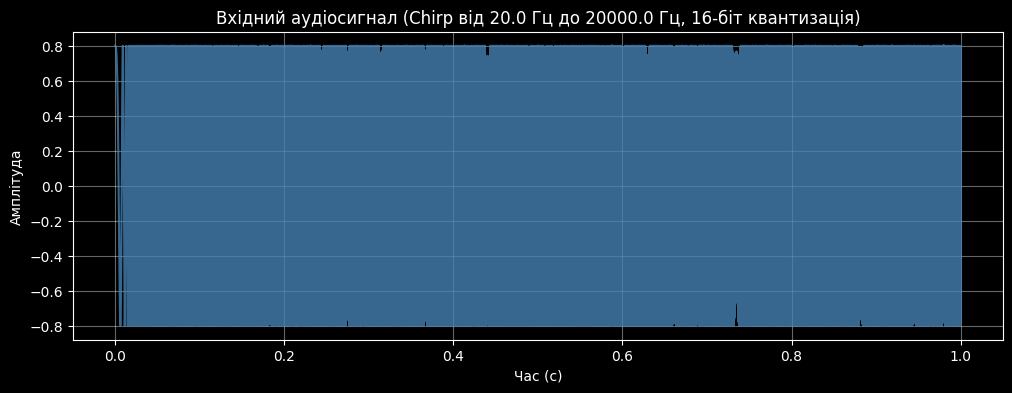

In [3]:
# Ввід даних (можна замінити на input() за потреби)
A_a = 0.8        # Амплітуда
f_1 = 20.0       # Початкова частота (Гц)
f_2 = 20000.0    # Кінцева частота (Гц)
f_s = 44100      # Частота дискретизації (CD якість)
duration = 1.0   # Тривалість 1 секунда

t = np.arange(0, duration, 1 / f_s)

# Генерація аудіосигналу (ЛЧМ / Chirp)
audio_signal = A_a * chirp(t, f0=f_1, t1=duration, f1=f_2, method='linear')

# Квантизація у 16 біт (PCM)
# Масштабуємо до діапазону int16: [-32768, 32767]
quantized_signal = np.int16(audio_signal * 32767)

# Повертаємо у float для подальшої математичної обробки фільтрами
signal_float = quantized_signal.astype(float) / 32767.0

# Візуалізація згенерованого сигналу
plt.figure(figsize=(12, 4))
plt.plot(t, signal_float, color='steelblue', alpha=0.8)
plt.title(f'Вхідний аудіосигнал (Chirp від {f_1} Гц до {f_2} Гц, 16-біт квантизація)')
plt.xlabel('Час (с)')
plt.ylabel('Амплітуда')
plt.grid(True, alpha=0.4)
plt.show()

## Розрахунок RIAA фільтрів та побудова графіків Боде
Стандарт RIAA визначається трьома часовими константами: $t_1 = 3180$ мкс, $t_2 = 318$ мкс, $t_3 = 75$ мкс. Зазвичай фільтри нормалізуються так, щоб мати підсилення 0 дБ на частоті 1 кГц.

### 2. РОЗРАХУНОК КОЕФІЦІЄНТІВ RIAA ФІЛЬТРІВ

In [4]:
t1, t2, t3 = 3180e-6, 318e-6, 75e-6

# Передавальна функція аналогового фільтра de-emphasis (відтворення)
# H(s) = (1 + s*t2) / ((1 + s*t1)*(1 + s*t3))
num_analog = [t2, 1.0]
den_analog = [t1 * t3, t1 + t3, 1.0]

# Білінійне перетворення для отримання цифрового IIR фільтра
b_de, a_de = bilinear(num_analog, den_analog, fs=f_s)

# Нормалізація фільтра (0 дБ на частоті 1 кГц)
w, h = freqz(b_de, a_de, worN=8000, fs=f_s)
idx_1k = np.argmin(np.abs(w - 1000))
gain_1k = np.abs(h[idx_1k])

b_de = b_de / gain_1k  # Нормалізований De-emphasis

# Фільтр Pre-emphasis (запис) є точною інверсією De-emphasis
# Перевертаємо чисельник та знаменник місцями
b_pre, a_pre = a_de, b_de

### 3. ВІЗУАЛІЗАЦІЯ ГРАФІКІВ БОДЕ

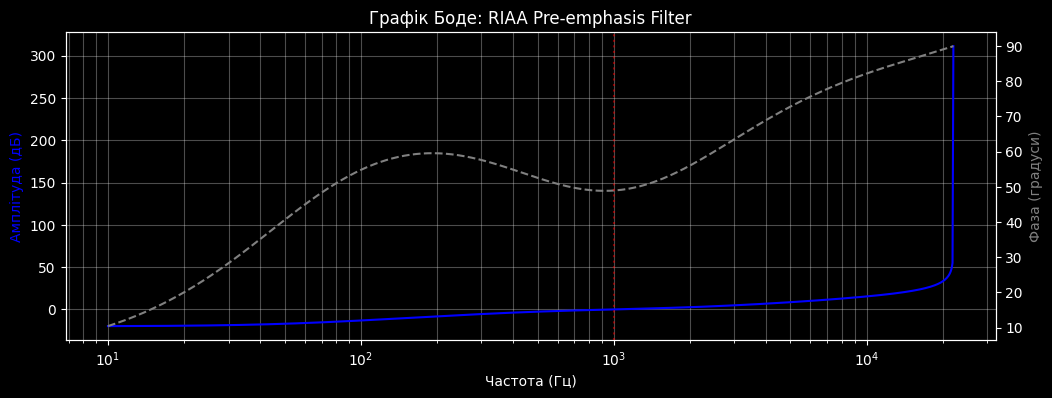

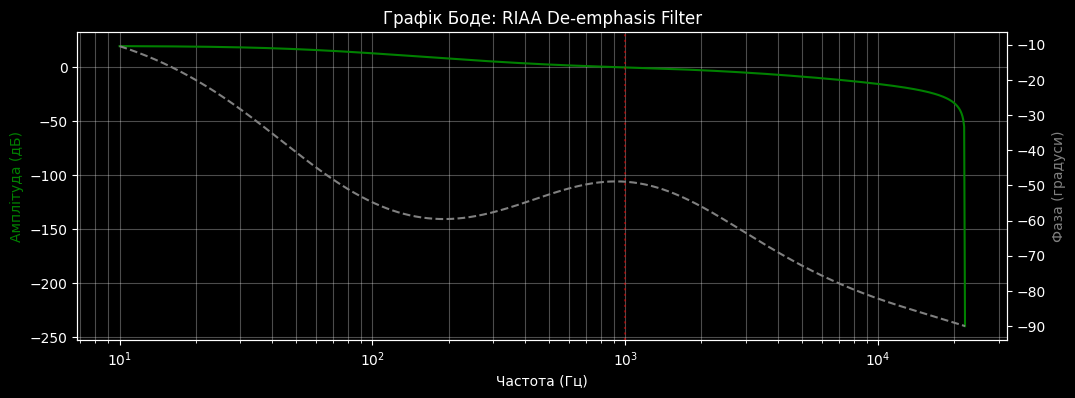

In [5]:
def plot_bode(b, a, title, color):
    w, h = freqz(b, a, worN=np.logspace(1, np.log10(f_s/2), 1000), fs=f_s)

    fig, ax1 = plt.subplots(figsize=(12, 4))

    # АЧХ
    ax1.set_title(f'Графік Боде: {title}')
    ax1.plot(w, 20 * np.log10(np.abs(h) + 1e-12), color)
    ax1.set_ylabel('Амплітуда (дБ)', color=color)
    ax1.set_xlabel('Частота (Гц)')
    ax1.set_xscale('log')
    ax1.grid(True, which='both', alpha=0.3)

    # ФЧХ
    ax2 = ax1.twinx()
    ax2.plot(w, np.angle(h, deg=True), color='gray', linestyle='--')
    ax2.set_ylabel('Фаза (градуси)', color='gray')

    plt.axvline(1000, color='red', linestyle=':', alpha=0.5, label='1 кГц (0 дБ)')
    plt.show()

plot_bode(b_pre, a_pre, 'RIAA Pre-emphasis Filter', 'blue')
plot_bode(b_de, a_de, 'RIAA De-emphasis Filter', 'green')

## Застосування фільтрів до сигналу
Цифрова фільтрація виконується за допомогою функції `lfilter`.
Оскільки частота нашого ЛЧМ-сигналу зростає з часом, ми побачимо, як амплітуда сигналу після pre-emphasis збільшується до кінця (підсилення високих частот), а після de-emphasis — повертається до початкового стану.

### 4. ФІЛЬТРАЦІЯ ТА ВІЗУАЛІЗАЦІЯ РЕЗУЛЬТАТІВ

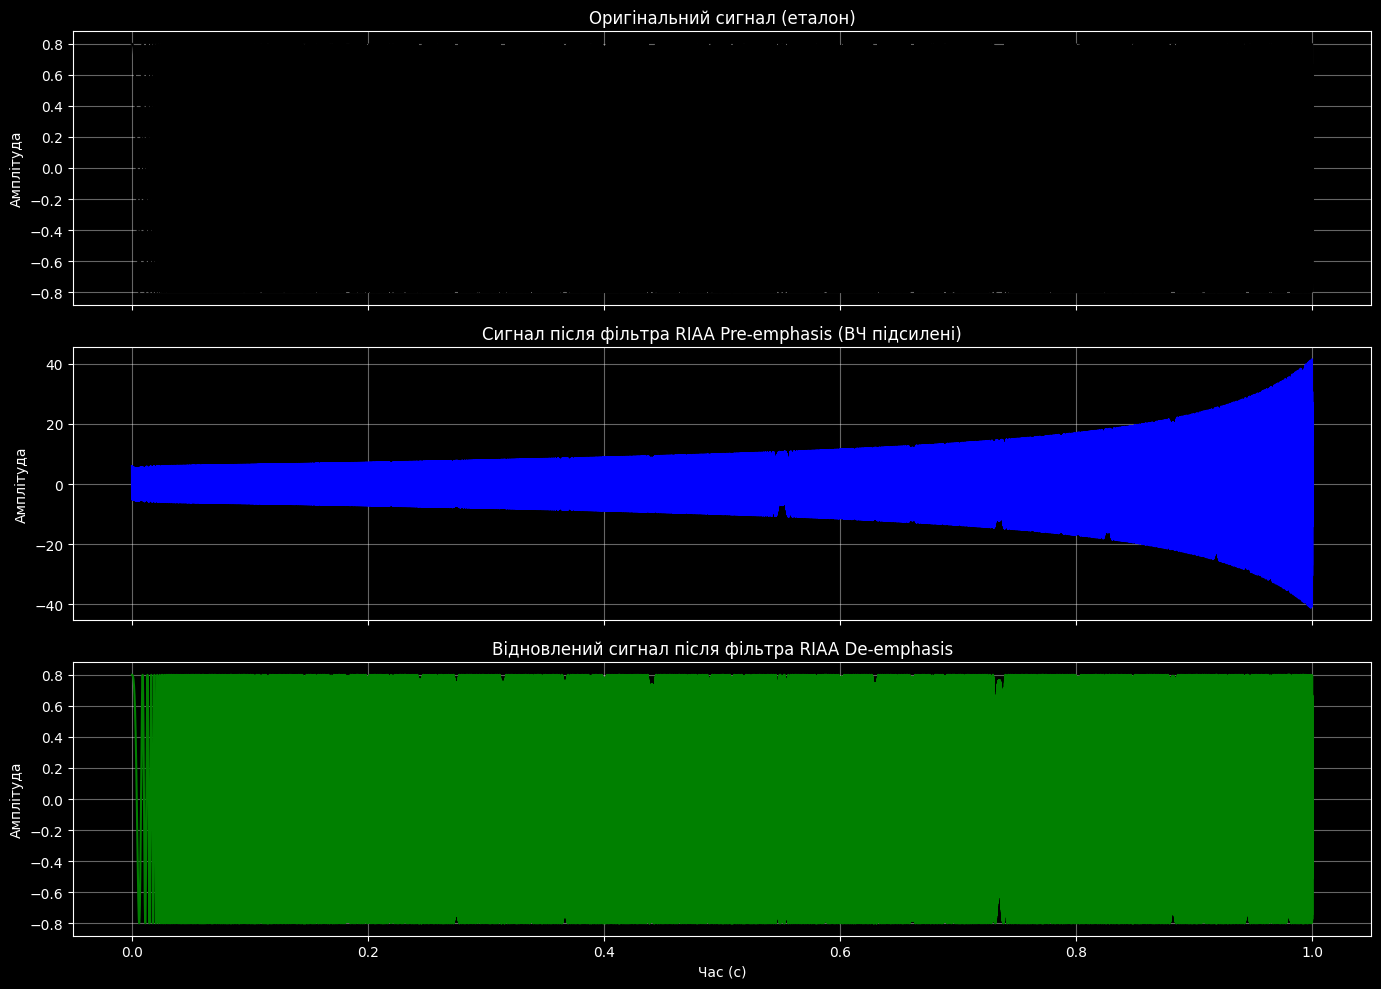

In [6]:
# 1. Застосовуємо Pre-emphasis
signal_pre_emphasis = lfilter(b_pre, a_pre, signal_float)

# 2. Застосовуємо De-emphasis до вже відфільтрованого сигналу
signal_reconstructed = lfilter(b_de, a_de, signal_pre_emphasis)

# Візуалізація
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Оригінальний сигнал
ax1.plot(t, signal_float, color='black')
ax1.set_title('Оригінальний сигнал (еталон)')
ax1.set_ylabel('Амплітуда')
ax1.grid(True, alpha=0.4)

# Після Pre-emphasis
ax2.plot(t, signal_pre_emphasis, color='blue')
ax2.set_title('Сигнал після фільтра RIAA Pre-emphasis (ВЧ підсилені)')
ax2.set_ylabel('Амплітуда')
ax2.grid(True, alpha=0.4)

# Після De-emphasis
ax3.plot(t, signal_reconstructed, color='green')
ax3.set_title('Відновлений сигнал після фільтра RIAA De-emphasis')
ax3.set_xlabel('Час (с)')
ax3.set_ylabel('Амплітуда')
ax3.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()